<a href="https://colab.research.google.com/github/yesahek/Machine_Learning/blob/main/Clustering%20With%20Unsupervised%20Learning/CodingKmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
from google.colab import drive
from google.colab import files
drive.mount('/content/drive')

In [22]:
data = pd.read_csv('/content/drive/MyDrive/ca-superfans.csv')
print(f"Dataset Shape {data.shape}")
data.head()

Dataset Shape (20640, 2)


,longitude,latitude
0,-122.23,37.88
1,-122.22,37.86
2,-122.24,37.85
3,-122.25,37.85
4,-122.25,37.85


## Visualization

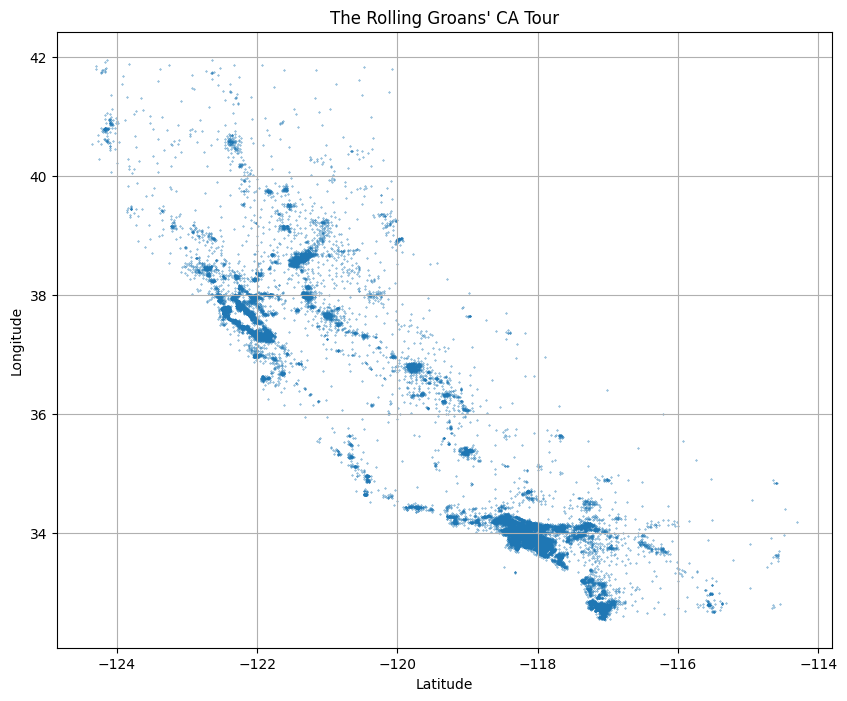

In [23]:
fig, ax = plt.subplots(figsize=(10,8))

ax.scatter(data["longitude"], data["latitude"], s=0.1)

ax.set(xlabel='Latitude', ylabel='Longitude',
       title="The Rolling Groans' CA Tour")
ax.grid()
plt.show()

## Elbow Method


In [24]:
inertias = []
clusters = range(2,20)
for cluster in clusters:
  kmeans = KMeans(n_clusters=cluster)
  kmeans.fit(data)
  inertias.append(kmeans.inertia_)

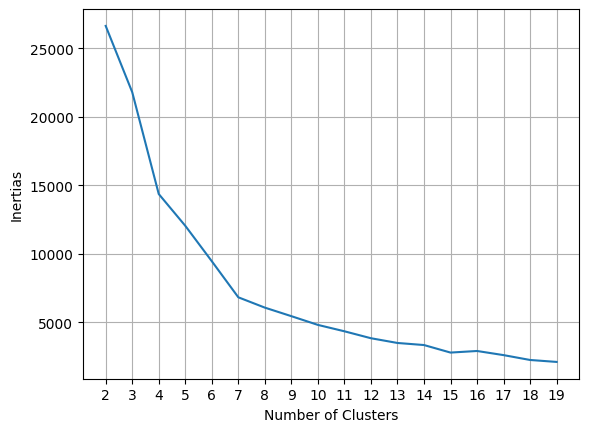

In [25]:
plt.plot(clusters, inertias)
plt.xticks(clusters)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertias")
plt.grid(True)
plt.show()

## Choosing $k$ and plotting the model

In [27]:
kmeans = KMeans(6)
kmeans.fit(data)

KMeans(n_clusters=6)

## Visualizing the model

<Axes: xlabel='latitude', ylabel='longitude'>

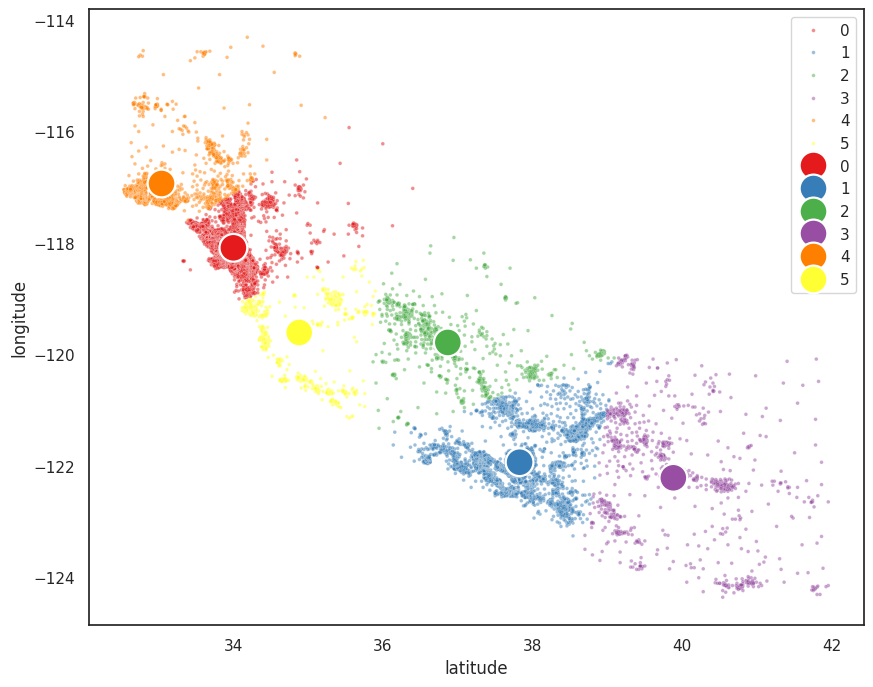

In [28]:
import seaborn as sns

sns.set(rc = {'figure.figsize':(10,8)},
        style="white", color_codes=True)

combined_df = pd.concat([data, pd.DataFrame({'CLUSTER':kmeans.labels_})], axis=1)

a = sns.scatterplot(x="latitude", y="longitude", palette='Set1', hue="CLUSTER",
                    data=combined_df, alpha=0.5, s=7)

label_index = []
for idx, label in enumerate(kmeans.cluster_centers_):
  label_index.append(idx)
sns.scatterplot(x=kmeans.cluster_centers_[:,1],y=kmeans.cluster_centers_[:,0], palette='Set1', hue=label_index, s=400)

In [29]:
print(kmeans.cluster_centers_)

[[-118.08531419   34.00462931]
 [-121.92916998   37.82709035]
 [-119.78163331   36.86843875]
 [-122.20856333   39.88077505]
 [-116.93196998   33.04512195]
 [-119.60361723   34.88359719]]
